# STEP 5. Configurational backbone: 고 NACH 각도 연속 stroke (N2의 원자료)

**질문(N2)**: 두 공원이 **같은 주요 보행 configurational 구조**(도시 이동 구조의 핵심 회랑)에 함께 붙어 있는가?

N1은 두 공원 사이의 경로 자체(쌍별 관계)를 묻는다. N2는 도시 전체 이동 구조가 정한 **회랑에 공동 소속되는지**를 묻는다. 그래서 두 공원이 서로 멀어도, 같은 회랑 위에 있으면 연결된다.

**방법**
1. `CityNetwork.centrality_simplest(distances=[800, 1600, 3200])` → 각도 choice(`cc_betweenness_{r}_ang`)와 각도 farness(`cc_farness_{r}_ang` = Σ(1 + c/90), 직각 단위의 총 각도 깊이).
2. **NACH 유사 정규화**: $\text{NACH}_r = \log(\text{choice}_r + 1) / \log(\text{farness}_r + 3)$ (Hillier et al. 2012 형식). raw choice는 밀도에 따라 부풀려져 맨해튼이 지배하므로 정규화가 필요하다. 수치가 DepthmapX와 동일하지는 않아 "NACH 유사"로 부른다.
3. **각도 연속 stroke** (cityseer 이후의 커스텀 연산): 각 교차점에서 들어오고 나가는 방향 편차가 가장 작은 세그먼트 짝을 차례로 짝지어(every-best-fit, 편차 < 30°) union-find로 잇는다. axial line / natural street에 근사한다.
4. stroke 길이 가중 평균 NACH 상위 **p% (네트워크 연장 기준)** stroke = **corridor**, p ∈ {2, 5, 10}%.
5. 공원이 attachment 세그먼트를 통해 corridor stroke 위에 있으면 소속으로 본다. stroke 위의 선형 위치(구간)도 저장해 회랑을 따라가는 거리 안전 한계를 둔다.

**계산 범위**: N2는 **주 변형 C에서만** 계산한다. 보도망(S)의 stroke는 길 양쪽 보도를 따라 평행하게 생겨 "회랑" 개념이 흐려지고, 각도 중심성 계산량도 C의 약 9배(노드 2.5배 × 도달 범위 3배)다. 3200 m 반경 betweenness는 cityseer의 적응형 표본추출(`sample=True`, Hoeffding ε = 0.05)로 계산한다.

**출력**: `Data/derived/{AREA}/centrality_{v}.parquet`, `strokes_{v}.parquet`, `park_stroke_{v}.parquet`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# N2 configurational corridor
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=Brooklyn  boroughs=['B']  AREA_DIR=Data/derived/Brooklyn


In [2]:
import logging
import shapely
from cityseer.network import CityNetwork
import matplotlib.pyplot as plt

logging.getLogger("cityseer").setLevel(logging.WARNING)
CN_DIR = NET_DIR / "cityseer"
parks = gpd.read_parquet(NET_DIR / "parks.parquet")
att = pd.read_parquet(NET_DIR / "attachments.parquet")
boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough")
N2_VARIANTS = [PRIMARY]

## 5-1. 각도 중심성 (cityseer)
보로 네트워크별로 계산하고 live 세그먼트 값만 모은다. 버퍼가 R_MAX(3.2 km)이므로 3200 m 반경까지 경계 효과가 없다.

In [3]:
def borough_centrality(v, b):
    f = AREA_DIR / f"centrality_{v}_{b}.parquet"
    if f.exists():
        return pd.read_parquet(f)
    t0 = time.time()
    cn = CityNetwork.load(CN_DIR / f"cn_{v}_{b}")
    n = len(cn.nodes_gdf)
    cn.centrality_simplest(distances=N2_RADII,
                           closeness={"farness": "1 + c / 90", "density": "1"},
                           betweenness={"betweenness": "1"}, postprocess={},
                           sample=True, random_seed=0)
    ng = cn.nodes_gdf
    cols = [c for c in ng.columns if c.startswith("cc_")]
    out = ng.loc[ng["live"], cols].copy()
    out.index.name = "seg_id"
    out["borough"] = b
    out.to_parquet(f)
    print(f"[{v}/{b}] centrality on {n:,} nodes in {time.time() - t0:.0f}s")
    return out


cent = {}
for v in N2_VARIANTS:
    c = pd.concat([borough_centrality(v, b) for b in AREA_BOROUGHS])
    c = c[~c.index.duplicated()]
    for r in N2_RADII:
        c[f"nach_{r}"] = np.log(c[f"cc_betweenness_{r}_ang"] + 1) / np.log(c[f"cc_farness_{r}_ang"] + 3)
    c.to_parquet(AREA_DIR / f"centrality_{v}.parquet")
    cent[v] = c
    print(v, len(c))
cent[PRIMARY][[f"nach_{r}" for r in N2_RADII] + [f"cc_betweenness_{r}_ang" for r in N2_RADII]].describe().round(3)

Parsing geometries:   0%|          | 0/166522 [00:00<?, ?it/s]

Parsing geometries:   4%|▍         | 7390/166522 [00:00<00:02, 73893.38it/s]

Parsing geometries:   9%|▉         | 14905/166522 [00:00<00:02, 74628.60it/s]

Parsing geometries:  14%|█▎        | 22498/166522 [00:00<00:01, 75222.12it/s]

Parsing geometries:  18%|█▊        | 30156/166522 [00:00<00:01, 75757.35it/s]

...

centrality simplest q~35%: 3200m: 100%|█████████▉| 166341/166522 [02:42<00:00, 1036.38it/s]

centrality simplest q~35%: 3200m: 100%|█████████▉| 166455/166522 [02:42<00:00, 914.78it/s] 

centrality simplest q~35%: 3200m: 100%|██████████| 166522/166522 [02:42<00:00, 1022.80it/s]

[C/B] centrality on 166,522 nodes in 514s
C 93188


,nach_800,nach_1600,nach_3200,cc_betweenness_800_ang,cc_betweenness_1600_ang,cc_betweenness_3200_ang
count,93188.000,93188.000,93188.000,93188.000,93188.000,93188.000
mean,0.946,0.966,0.964,4215.834,36267.491,256858.744
std,0.344,0.345,0.350,5003.064,44608.313,372116.725
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.872,0.874,0.863,759.750,3433.500,10796.864
50%,1.059,1.081,1.070,2635.000,19533.792,93447.495
75%,1.170,1.195,1.203,5997.062,54444.646,363550.796
max,1.375,1.373,1.399,73946.500,402212.250,3309096.239


## 5-2. 각도 연속 stroke
세그먼트 양 끝의 바깥쪽 방향 벡터(끝점에서 15 m 지점까지)를 쓴다. 두 세그먼트가 한 교차점에서 이어질 때의 편차 = 180° − (두 바깥 벡터 사이 각). 교차점마다 편차가 작은 짝부터 욕심껏(greedy) 짝지으므로, 세그먼트 끝 하나는 최대 한 번만 이어진다. 따라서 stroke는 단순 경로이거나 고리다.

In [4]:
def end_vectors(geoms, probe=15.0):
    L = shapely.length(geoms)
    p0 = shapely.get_point(geoms, 0)
    p1 = shapely.get_point(geoms, -1)
    q0 = shapely.line_interpolate_point(geoms, np.minimum(probe, L / 2))
    q1 = shapely.line_interpolate_point(geoms, np.maximum(L - probe, L / 2))
    v0 = np.c_[shapely.get_x(q0) - shapely.get_x(p0), shapely.get_y(q0) - shapely.get_y(p0)]
    v1 = np.c_[shapely.get_x(q1) - shapely.get_x(p1), shapely.get_y(q1) - shapely.get_y(p1)]
    k0 = list(zip(np.round(shapely.get_x(p0), 1), np.round(shapely.get_y(p0), 1)))
    k1 = list(zip(np.round(shapely.get_x(p1), 1), np.round(shapely.get_y(p1), 1)))
    return k0, k1, v0, v1


class UF:
    def __init__(self, n):
        self.p = np.arange(n)

    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]
            x = self.p[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[rb] = ra


def build_strokes(segs, max_defl):
    geoms = segs.geometry.values
    n = len(segs)
    k0, k1, v0, v1 = end_vectors(geoms)
    ends = pd.DataFrame({"seg": np.r_[np.arange(n), np.arange(n)], "side": np.r_[np.zeros(n, int), np.ones(n, int)],
                         "key": k0 + k1})
    vec = np.r_[v0, v1]
    norm = np.linalg.norm(vec, axis=1)
    norm[norm == 0] = 1
    vec = vec / norm[:, None]
    ends["e"] = np.arange(len(ends))
    seg_arr, side_arr = ends["seg"].values, ends["side"].values
    uf = UF(n)
    link = {}  # (seg, side) -> (seg, side)
    grp = ends.groupby("key")["e"].apply(list)
    grp = grp[grp.str.len() >= 2]
    for es in grp.values:
        cand = []
        for x in range(len(es)):
            for y in range(x + 1, len(es)):
                a, b = es[x], es[y]
                if seg_arr[a] == seg_arr[b]:
                    continue
                cosang = np.clip(np.dot(vec[a], vec[b]), -1, 1)
                defl = 180 - np.degrees(np.arccos(cosang))
                if defl < max_defl:
                    cand.append((defl, a, b))
        used = set()
        for defl, a, b in sorted(cand):
            if a in used or b in used:
                continue
            used.update((a, b))
            sa, sb = seg_arr[a], seg_arr[b]
            uf.union(sa, sb)
            link[(sa, side_arr[a])] = (sb, side_arr[b])
            link[(sb, side_arr[b])] = (sa, side_arr[a])
    stroke = np.array([uf.find(i) for i in range(n)])
    # 선형 위치: stroke의 한쪽 끝에서 체인을 따라 누적 길이
    L = shapely.length(geoms)
    pos = np.full(n, np.nan)
    for sid, members in pd.Series(np.arange(n)).groupby(stroke).groups.items():
        members = list(members)
        start, start_side = members[0], 0
        for m in members:  # 열린 끝을 가진 세그먼트에서 시작 (고리면 아무 곳)
            if (m, 0) not in link:
                start, start_side = m, 0
                break
            if (m, 1) not in link:
                start, start_side = m, 1
                break
        cur, entry, acc = start, start_side, 0.0
        seen = set()
        while cur not in seen:
            seen.add(cur)
            pos[cur] = acc + L[cur] / 2
            acc += L[cur]
            nxt = link.get((cur, 1 - entry))
            if nxt is None:
                break
            cur, entry = nxt
    return stroke, pos


segs_all = {}
for v in N2_VARIANTS:
    segs = gpd.read_parquet(NET_DIR / f"segments_{v}.parquet", columns=["seg_id", "kind", "geometry"])
    area = boroughs.loc[AREA_BOROUGHS].union_all().buffer(R_MAX)
    segs = segs.iloc[segs.sindex.query(area, predicate="intersects")].reset_index(drop=True)
    out = segs[["seg_id"]].copy()
    out["length"] = segs.length.values
    for ang in STROKE_ANGLE_GRID:
        t0 = time.time()
        stroke, pos = build_strokes(segs, ang)
        out[f"stroke_{ang}"] = stroke
        out[f"pos_{ang}"] = pos
        ns_ = pd.Series(stroke).value_counts()
        print(f"[{v}] angle<{ang}°: {len(ns_):,} strokes, mean segments/stroke {ns_.mean():.2f}, "
              f"max {ns_.max()}  ({time.time() - t0:.0f}s)")
    out.to_parquet(AREA_DIR / f"strokes_{v}.parquet")
    segs_all[v] = segs

[C] angle<20°: 39,092 strokes, mean segments/stroke 4.27, max 421  (2s)


[C] angle<30°: 35,600 strokes, mean segments/stroke 4.69, max 421  (3s)


[C] angle<45°: 32,419 strokes, mean segments/stroke 5.15, max 421  (3s)


## 5-3. corridor 선정과 공원-stroke 소속
- stroke별 NACH = live 세그먼트 NACH의 길이 가중 평균(버퍼의 dead 세그먼트는 NACH 없음)
- (r, p, stroke 각도) 조합마다 NACH 상위 stroke부터 누적 연장이 live 연장의 p%에 이를 때까지 선택 = corridor
- 공원-stroke: 공원 attachment(기본 d, 전부)가 속한 stroke와 그 stroke 위 선형 위치 구간 [pos_min, pos_max]

In [5]:
for v in N2_VARIANTS:
    st = pd.read_parquet(AREA_DIR / f"strokes_{v}.parquet").set_index("seg_id")
    c = cent[v]
    st = st.join(c[[f"nach_{r}" for r in N2_RADII]], how="left")
    live_len = st.loc[st[f"nach_{N2_RADII[0]}"].notna(), "length"].sum()
    corridor_rows = []
    for ang in STROKE_ANGLE_GRID:
        live = st[st[f"nach_{N2_RADII[0]}"].notna()]
        g = live.groupby(f"stroke_{ang}")
        tbl = pd.DataFrame({"length": g["length"].sum()})
        for r in N2_RADII:
            tbl[f"nach_{r}"] = (live[f"nach_{r}"] * live["length"]).groupby(live[f"stroke_{ang}"]).sum() / tbl["length"]
        for r in N2_RADII:
            order = tbl.sort_values(f"nach_{r}", ascending=False)
            cum = order["length"].cumsum() / live_len
            for p in N2_TOP_P:
                sel = order.index[cum <= p].tolist() or [order.index[0]]
                corridor_rows.append(pd.DataFrame({"angle": ang, "r": r, "p": p, "stroke": sel}))
    corr = pd.concat(corridor_rows, ignore_index=True)
    corr.to_parquet(AREA_DIR / f"corridors_{v}.parquet")

    a = att[(att.variant == v) & att.is_default][["park_id", "seg_id"]]
    a = a.join(st[[f"stroke_{g}" for g in STROKE_ANGLE_GRID] + [f"pos_{g}" for g in STROKE_ANGLE_GRID]], on="seg_id", how="inner")
    ps = []
    for ang in STROKE_ANGLE_GRID:
        g = a.groupby(["park_id", f"stroke_{ang}"])[f"pos_{ang}"].agg(["min", "max"]).reset_index()
        g.columns = ["park_id", "stroke", "pos_min", "pos_max"]
        g["angle"] = ang
        ps.append(g)
    pd.concat(ps, ignore_index=True).to_parquet(AREA_DIR / f"park_stroke_{v}.parquet")
    print(f"[{v}] corridors: {corr.groupby(['angle', 'r', 'p']).size().describe()[['min', 'max']].to_dict()}")

[C] corridors: {'min': 22.0, 'max': 211.0}


## 5-4. 진단: corridor 구조와 공원 소속
corridor가 하나의 거대 연결요소로 뭉치면 "같은 구조 공유"가 곧 모두 연결로 무너진다. stroke 단위 소속은 이 문제를 피한다. 여기서는 corridor별로 몇 개 공원이 붙는지 분포를 확인한다.

In [6]:
diag = []
for v in N2_VARIANTS:
    corr = pd.read_parquet(AREA_DIR / f"corridors_{v}.parquet")
    ps = pd.read_parquet(AREA_DIR / f"park_stroke_{v}.parquet")
    focal = parks.index[parks.borough.isin(AREA_BOROUGHS) & parks.in_main]
    ps = ps[ps.park_id.isin(focal)]
    for (ang, r, p), g in corr.groupby(["angle", "r", "p"]):
        m = ps[(ps.angle == ang) & ps.stroke.isin(g.stroke)]
        per = m.groupby("stroke").park_id.nunique()
        diag.append(dict(variant=v, angle=ang, r=r, p=p, corridors=len(g), parks_on_corridor=m.park_id.nunique(),
                         share_parks=m.park_id.nunique() / len(focal), max_parks_per_corridor=per.max() if len(per) else 0,
                         median_parks_per_corridor=per.median() if len(per) else 0))
diag = pd.DataFrame(diag)
diag.to_csv(AREA_DIR / "corridor_diagnostics.csv", index=False)
diag[diag.angle == STROKE_ANGLE].round(3)

,variant,angle,r,p,corridors,parks_on_corridor,share_parks,max_parks_per_corridor,median_parks_per_corridor
9,C,30,800,0.02,49,51,0.085,8,2.0
10,C,30,800,0.05,93,141,0.235,12,2.0
11,C,30,800,0.10,170,218,0.364,12,2.0
12,C,30,1600,0.02,31,48,0.080,6,2.5
13,C,30,1600,0.05,71,116,0.194,11,2.0
14,C,30,1600,0.10,131,220,0.367,12,2.0
15,C,30,3200,0.02,25,46,0.077,11,3.0
16,C,30,3200,0.05,55,106,0.177,11,3.0
17,C,30,3200,0.10,109,190,0.317,15,2.0


## 5-5. 지도: NACH 1600과 corridor (주 변형, p=5%, 30°)

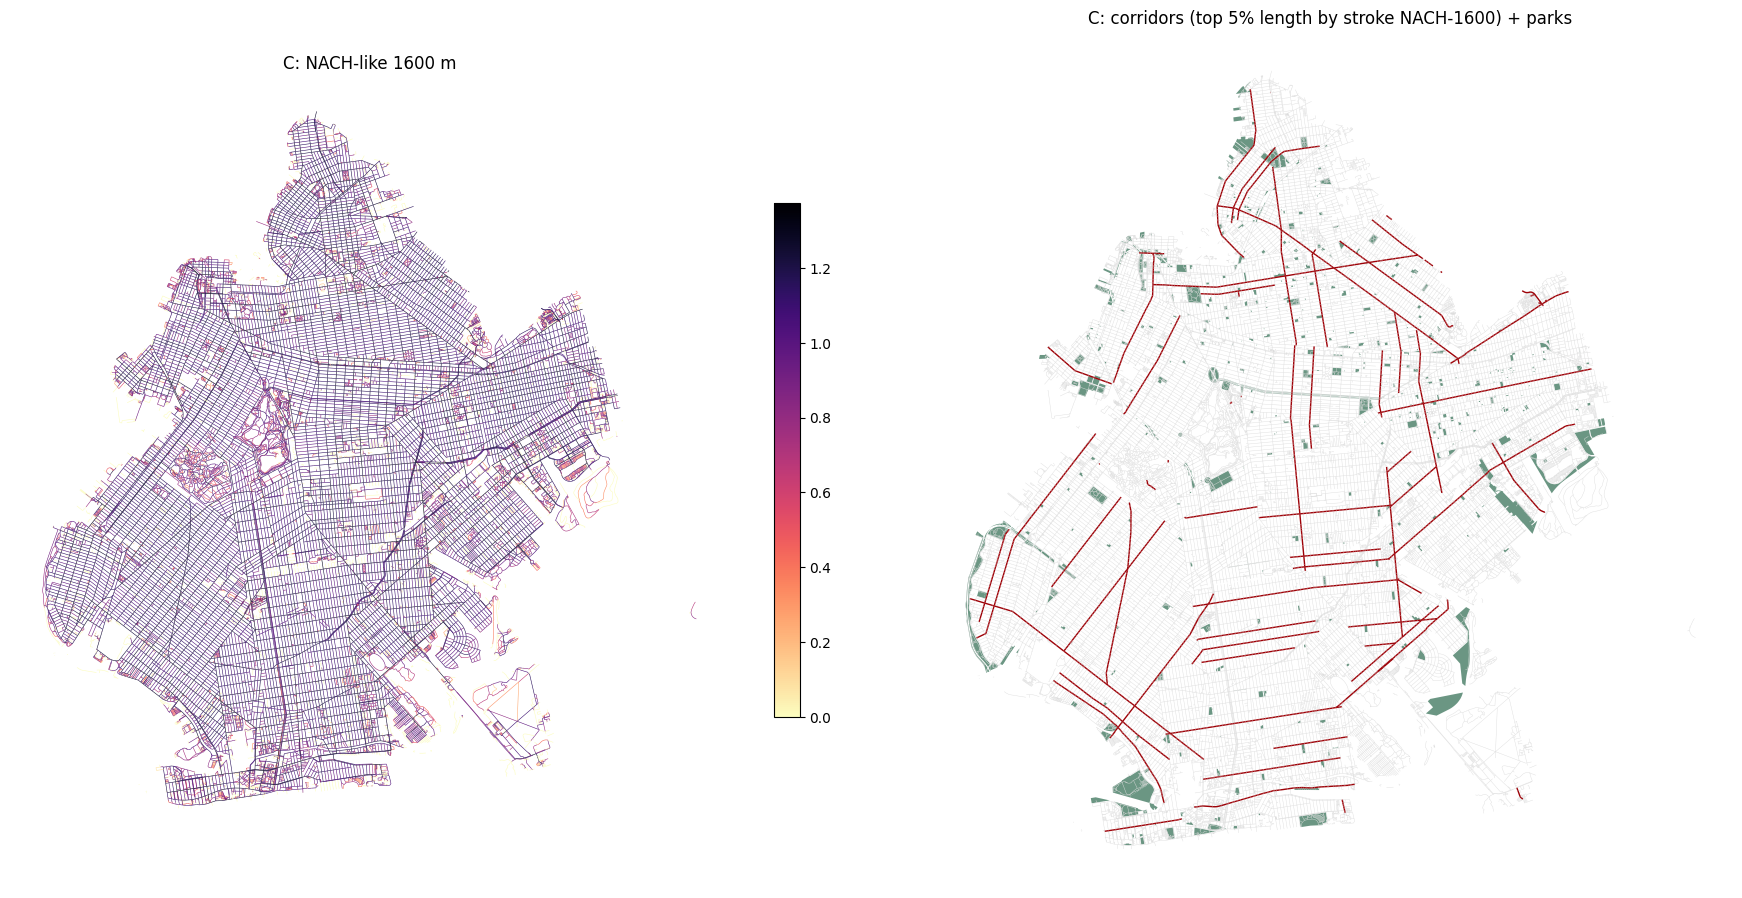

In [7]:
v = PRIMARY
st = pd.read_parquet(AREA_DIR / f"strokes_{v}.parquet").set_index("seg_id")
corr = pd.read_parquet(AREA_DIR / f"corridors_{v}.parquet")
sel = corr[(corr.angle == STROKE_ANGLE) & (corr.r == 1600) & (corr.p == 0.05)].stroke
g = segs_all[v].set_index("seg_id").join(cent[v][["nach_1600"]], how="inner")
g["corridor"] = st.loc[g.index, f"stroke_{STROKE_ANGLE}"].isin(sel).values
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
g.plot(ax=axes[0], column="nach_1600", cmap="magma_r", linewidth=0.4, legend=True, legend_kwds={"shrink": 0.6})
axes[0].set_title(f"{v}: NACH-like 1600 m")
g[~g.corridor].plot(ax=axes[1], color="#dddddd", linewidth=0.3)
g[g.corridor].plot(ax=axes[1], color="#9d0208", linewidth=1.0)
parks[parks.borough.isin(AREA_BOROUGHS) & parks.in_main].plot(ax=axes[1], color="#2d6a4f", alpha=0.7)
axes[1].set_title(f"{v}: corridors (top 5% length by stroke NACH-1600) + parks")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()